# MongoDB Exploratory Data Analysis (EDA) Case Study

---

## Student Information

| Particular | Details |
|------------|---------|
| Student Name | __________________________ |
| Roll Number | __________________________ |
| Branch | CSE-AI |
| Year & Semester | IV Year & I Semester |
| Subject | NoSQL Databases |
| Case Study Title | Exploratory Data Analysis (EDA) using MongoDB |
| Faculty Name | Mr B A V L Sainadh |
| Date | __________________________ |

---

# Dataset Information

| Attribute | Details |
|-----------|---------|
| Dataset Name | sample_supplies |
| Database Name | sample_supplies |
| Collection Name | sales |
| Business Domain | Retail Sales |
| Data Source | MongoDB Sample Dataset |

## Dataset Description

The **sample_supplies** dataset contains retail sales transactions of an office supplies company. Each document represents a single sales transaction and includes customer information, purchased products, store location, purchase method, and transaction date.

The dataset follows MongoDB's document-oriented data model, where related information is stored together in a single document using embedded documents and arrays. This structure enables efficient storage and retrieval of semi-structured business data.

# Case Study Overview

Retail organizations generate thousands of sales transactions every day. Analyzing these transactions helps businesses understand customer behavior, evaluate store performance, identify sales trends, and make informed business decisions.

In this case study, MongoDB is used as the primary data source for performing **Exploratory Data Analysis (EDA)**. Using **PyMongo**, we will query the sales data, analyze key business metrics, and visualize the results to gain meaningful business insights.

This notebook demonstrates a typical data analysis workflow using MongoDB and serves as a sample EDA case study. Students can use the same methodology to analyze different MongoDB datasets in future assignments.

# Business Objectives

The primary objectives of this case study are to:

- Understand the structure of the MongoDB dataset.
- Explore the sales transaction data using PyMongo.
- Perform exploratory data analysis (EDA) on business data.
- Answer business questions using MongoDB queries.
- Visualize analytical results using Python.
- Interpret the findings and derive meaningful business insights.
- Provide actionable recommendations based on the analysis.

# Case Study Workflow

The case study follows the standard Exploratory Data Analysis (EDA) workflow used in data analytics projects.

1. Environment Setup
2. Understand the Dataset
3. Perform Exploratory Data Analysis
4. Visualize Results
5. Generate Business Insights
6. Provide Actionable Recommendations

By following this workflow, raw business data is transformed into meaningful information that supports effective decision-making.

# Environment Setup

Before starting the exploratory data analysis, we need to prepare the Python environment and establish a connection with the local MongoDB Community Server.

This section imports the required Python libraries, configures the notebook for better readability, and connects to the MongoDB database containing the business dataset.

## Import Required Libraries

The following libraries are used throughout this case study:

- **PyMongo** – Connect to MongoDB and execute queries.
- **Pandas** – Data manipulation and tabular analysis.
- **NumPy** – Numerical operations.
- **Matplotlib** – Data visualization.
- **Seaborn** – Statistical data visualization.
- **pprint** – Display MongoDB documents in a readable format.

In [1]:
from pymongo import MongoClient

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint

## Configure Notebook Settings

Configure display options to improve the readability of tables and visualizations throughout the notebook.

In [2]:
# Pandas Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

## Connect to MongoDB

Create a connection to the local MongoDB Community Server.

In [3]:
client = MongoClient("mongodb://localhost:27017")

# Dataset Setup

Before starting this case study, the **sample_supplies** dataset must be imported into your local MongoDB Community Server.

This is a one-time setup process. Once imported, the dataset remains available in your local MongoDB instance until it is deleted.

## Step 1: Download the Dataset

The dataset used in this case study is available from the following GitHub repository:

https://github.com/neelabalan/mongodb-sample-dataset

Download or clone the repository and locate the following file:

```

mongodb-sample-dataset/
└── sample_supplies/
    └── sales.json

```

This file contains the sales transaction data used throughout this notebook.

## Step 2: Import the Dataset into MongoDB

Open **Command Prompt** or **PowerShell** and execute the following command.

Replace the file path with the location of **sales.json** on your computer.

In [4]:
!mongoimport --db sample_supplies --collection sales --file "C:\path\to\sales.json..................(Add the correct path to your sales.json file here).................."

'mongoimport' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
!mongoimport --db sample_supplies --collection sales --file "C:\path\to\sales.json"

If the import is successful, MongoDB will create:

- **Database:** `sample_supplies`
- **Collection:** `sales`

The dataset is now ready for analysis using PyMongo.

## Connect to the Database and Collection

Connect to the **sample_supplies** database and access the **sales** collection, which will be used throughout this case study.

In [5]:
db = client["sample_supplies"]

sales = db["sales"]

## Verify the Connection

Before beginning the analysis, verify that the collection is accessible and contains data.

In [6]:
print(f"Database   : {db.name}")
print(f"Collection : {sales.name}")
print(f"Documents  : {sales.count_documents({}):,}")

Database   : sample_supplies
Collection : sales
Documents  : 5,000


# Question 1: What is the total number of sales transactions recorded in the dataset?

## Business Objective

Management wants to determine the total number of sales transactions recorded by the business. This metric provides an overview of the business activity and serves as a baseline Key Performance Indicator (KPI) for further analysis.

## Code for Query

In [7]:
total_transactions = sales.count_documents({})

print(total_transactions)

5000


## Code for Visualization

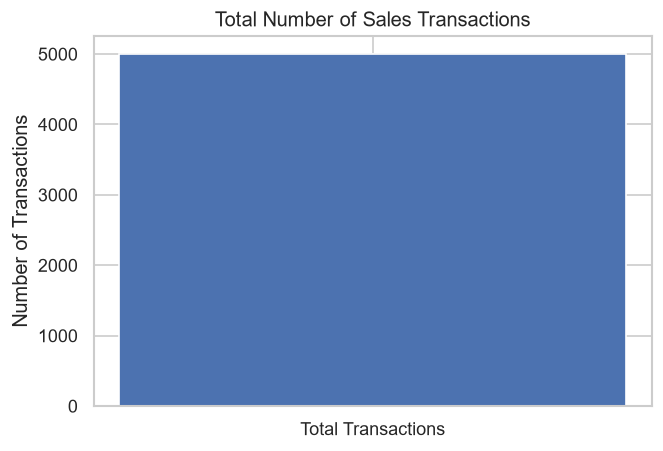

In [8]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Total Transactions"],
    [total_transactions]
)

plt.title("Total Number of Sales Transactions")

plt.ylabel("Number of Transactions")

plt.show()

# Question 2: How many sales transactions were processed by each store location, and how do the transaction volumes compare across different store locations?

## Business Objective

Management wants to compare the number of sales transactions processed by each store location to identify stores with higher and lower customer activity. This analysis helps support resource allocation, inventory planning, and operational decision-making across different business locations.

## Code for Query

In [9]:
pipeline = [
    {
        "$group": {
            "_id": "$storeLocation",
            "transactions": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "transactions": -1
        }
    }
]

result = list(sales.aggregate(pipeline))

store_transactions = pd.DataFrame(result)

store_transactions

,_id,transactions
0,Denver,1549
1,Seattle,1134
2,London,794
3,Austin,676
4,New York,501
5,San Diego,346


## Code for Visualization

In [10]:
store_transactions.rename(
    columns={"_id": "Store Location"},
    inplace=True
)

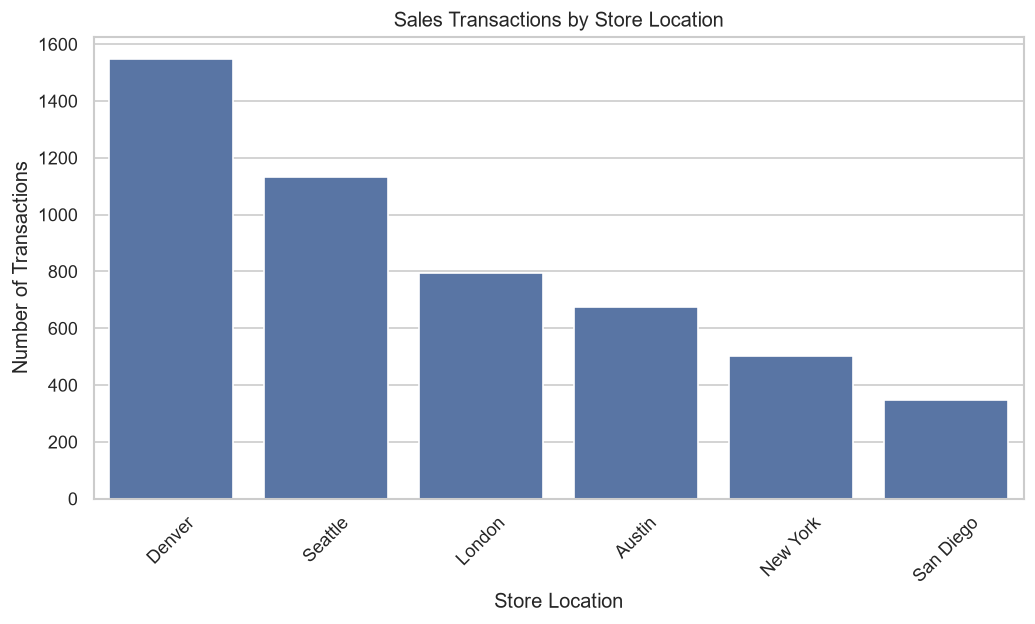

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=store_transactions,
    x="Store Location",
    y="transactions"
)

plt.title("Sales Transactions by Store Location")

plt.xlabel("Store Location")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

# Question 3: How many sales transactions were completed using each purchase method, and how do customers' purchasing preferences compare across different purchase methods?

## Business Objective

The company offers multiple purchase methods, such as **In-store**, **Online**, and **Phone**. Management wants to compare the number of sales transactions completed through each purchase method to understand customers' purchasing preferences. This analysis helps evaluate the popularity of different sales channels and supports decisions related to customer service, sales strategy, and resource allocation.

## Code for Query

## Code for Visualization

# Question 4: How many sales transactions were completed using coupons, and how many were completed without using coupons?

## Business Objective

Management wants to evaluate customer adoption of promotional coupons by comparing the number of sales transactions completed using coupons with those completed without coupons.

This analysis helps assess the effectiveness of coupon-based promotional campaigns and understand customers' purchasing behavior.

## Code for Query

## Code for Visualization

# Question 5: How many sales transactions were recorded in each year?

## Business Objective

Management wants to compare the number of sales transactions recorded each year to understand how business activity has changed over time.

Analyzing annual transaction volumes helps identify long-term business trends and supports strategic planning.

## Code for Query

## Code for Visualization

# Question 6: How many sales transactions were recorded in each month, and are there any seasonal variations in transaction volume?

## Business Objective

Management wants to compare the number of sales transactions recorded in each month to identify seasonal variations in customer purchasing activity.

Understanding monthly transaction patterns helps the business plan inventory levels, staffing requirements, and promotional campaigns during periods of high and low customer demand.

## Code for Query

## Code for Visualization

# Question 7: How many unique products are sold by the business, and what are their names?

## Business Objective

Management wants to identify the number of unique products offered by the business and obtain the complete list of products available for sale.

Understanding the product portfolio helps the business evaluate product diversity, support inventory planning, and assist in future product management decisions.

## Code for Query

## Code for Visualization

# Question 8: What is the average customer satisfaction rating of all customers in the dataset?

## Business Objective

Management wants to determine the overall average customer satisfaction rating to evaluate the quality of the shopping experience provided by the business.

Monitoring customer satisfaction helps assess overall service quality and provides a baseline for future comparisons across store locations, purchase methods, and customer segments.

## Code for Query

## Code for Visualization

# Question 9: Which products have the highest total quantity sold across all sales transactions?

## Business Objective

Management wants to identify the products with the highest total quantity sold across all sales transactions.

Since each sales transaction may contain multiple purchased products, the analysis requires examining every product within the `items` array and calculating the total quantity sold for each product. Identifying high-demand products helps the business optimize inventory management, improve procurement planning, and ensure that popular products remain readily available to customers.

## Code for Query

## Code for Visualization

# Question 10: Which products generated the highest total sales revenue across all sales transactions?

## Business Objective

Management wants to identify the products that generated the highest total sales revenue.

Unlike the previous analysis, which focused on the quantity sold, this analysis considers both the **selling price** and **quantity sold** to determine the revenue contribution of each product. Understanding product revenue helps the business prioritize high-value products, improve inventory planning, and develop effective sales and marketing strategies.

## Code for Query

## Code for Visualization

# Question 11: Which store locations generated the highest total sales revenue?

## Business Objective

Management wants to compare the sales performance of different store locations based on the total revenue generated.

This analysis calculates the total sales revenue for each store by considering both the selling price and quantity of every product sold. Comparing revenue across store locations helps identify high-performing stores, supports strategic decision-making, and assists in resource allocation, inventory planning, and future business expansion.

## Code for Query

## Code for Visualization

# Question 12: How much total sales revenue was generated through each purchase method?

## Business Objective

Management wants to compare the revenue generated through different purchase methods, including **In-store**, **Online**, and **Phone** sales.

While previous analyses compared the number of transactions for each purchase method, this analysis focuses on **total sales revenue**. Understanding revenue contribution by purchase channel helps businesses evaluate channel performance, optimize sales strategies, and allocate resources effectively across different customer purchasing channels.

## Code for Query

## Code for Visualization

# Question 13: What is the average transaction value for each store location?

## Business Objective

Management wants to compare the **average transaction value** across different store locations.

Since each sales transaction may contain multiple purchased products, the transaction value is calculated by summing the revenue generated from every product within a transaction (Quantity × Price). The average transaction value helps identify stores where customers spend more per purchase, enabling better pricing strategies, promotional planning, customer segmentation, and revenue optimization.

## Code for Query

## Code for Visualization

# Question 14: Which products generated the highest sales revenue from transactions where a coupon was used?

## Business Objective

Management wants to evaluate the effectiveness of coupon-based sales by identifying the products that generated the highest revenue from transactions where customers used coupons.

This analysis filters only the transactions in which a coupon was applied and calculates the total revenue generated by each product. The results help businesses understand which products perform well during promotional campaigns and support future marketing and discount strategies.

## Code for Query

## Code for Visualization

# Question 15: What is the average selling price of each product?

## Business Objective

Management wants to determine the average selling price of each product across all sales transactions.

This analysis calculates the average selling price for every product, helping the business understand pricing trends across its product portfolio. The results can support pricing decisions, product positioning, competitor analysis, and future pricing strategies.

## Code for Query

## Code for Visualization

# Question 16: How can we calculate the total value of each sales transaction using MongoDB Aggregation?

## Business Objective

Management wants to determine the monetary value of every sales transaction.

Since each transaction contains multiple purchased products, the total transaction value is calculated by summing the revenue generated by all products in that transaction. This analysis helps identify high-value and low-value purchases, supports customer spending analysis, and forms the foundation for advanced business analytics such as customer segmentation and sales forecasting.

Unlike previous analyses that summarized the entire dataset, this question calculates the value of **every individual transaction**, demonstrating how MongoDB can generate derived business metrics using aggregation pipelines.

## Code for Query

# Question 17: How many sales transactions are classified as High Value and Low Value based on their transaction amount?

## Business Objective

Management wants to classify sales transactions into **High Value** and **Low Value** categories based on their total transaction amount.

This analysis first calculates the total value of each transaction and then uses a conditional expression to categorize transactions. Such classifications help businesses identify premium purchases, analyze customer spending behavior, and develop targeted marketing campaigns for different customer segments.

## Code for Query

## Code for Visualization

# Question 18: How are sales transactions distributed across different transaction value ranges?

## Business Objective

Management wants to understand how sales transactions are distributed across different transaction value ranges.

Instead of simply classifying transactions as High Value or Low Value, this analysis groups transactions into multiple spending ranges. Understanding the distribution of transaction values helps businesses identify common purchasing patterns, evaluate customer spending behavior, and develop pricing and promotional strategies for different customer segments.

## Code for Visualization

# Question 19: How can multiple business summaries be generated simultaneously using MongoDB's `$facet` stage?

## Business Objective

Management requires multiple business summaries from the sales dataset, including transaction counts by purchase method, transaction counts by store location, and coupon usage statistics.

Instead of executing separate aggregation queries for each report, MongoDB's **`$facet`** stage allows multiple independent aggregation pipelines to run simultaneously, reducing database queries and improving reporting efficiency.

## Code for Query

# Question 20: How can an Executive Business Dashboard be created using MongoDB Aggregation and Python?

## Business Objective

Senior management requires an Executive Business Dashboard that provides a quick overview of the organization's overall sales performance.

Instead of examining individual reports separately, businesses often consolidate multiple Key Performance Indicators (KPIs) and visualizations into a single dashboard. Such dashboards enable executives to monitor business performance, identify trends, and make informed strategic decisions.

The dashboard summarizes the following business metrics:

- Total Sales Transactions
- Total Sales Revenue
- Average Customer Satisfaction
- Store Performance
- Purchase Method Distribution
- Coupon Usage Distribution

This dashboard combines the analytical results obtained throughout the case study into a single visual report.

## Code for Executive Business Dashboard